In [1]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# NLP
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Optional: for nicer plots in notebook
%matplotlib inline
sns.set(style="whitegrid")

In [4]:
# Paths (adjust to your notebook layout)
sales_fp = "sales_profit.csv"
demo_fp = "demo_manchester.csv"
reviews_fp = "reviews.csv"

# Load CSVs
sales_df = pd.read_csv(sales_fp, parse_dates=["date"])
demo_df = pd.read_csv(demo_fp)
reviews_df = pd.read_csv(reviews_fp)

In [5]:
print("Sales rows:", len(sales_df))
print("Demographics rows:", len(demo_df))
print("Reviews rows:", len(reviews_df))

sales_df.head()

Sales rows: 2
Demographics rows: 10
Reviews rows: 15


,date,store_id,product,units_sold,unit_price,unit_cost,promotion_flag,sale_channel,customer_id,notes
0,2025-01-01,1,Tofu Pudding,20,4.0,1.5,0,in-store,1001,NaN
1,2025-01-01,1,Korean Bingsu,5,8.5,3.0,1,in-store,1002,New Year promo


In [6]:
# Compute total revenue, cost, profit
sales_df["revenue"] = sales_df["units_sold"] * sales_df["unit_price"]
sales_df["cost"] = sales_df["units_sold"] * sales_df["unit_cost"]
sales_df["profit"] = sales_df["revenue"] - sales_df["cost"]

# Profit margin percent
sales_df["profit_margin_pct"] = np.where(
    sales_df["revenue"] > 0,
    100 * sales_df["profit"] / sales_df["revenue"],
    np.nan
)

sales_df.head()

,date,store_id,product,units_sold,unit_price,unit_cost,promotion_flag,sale_channel,customer_id,notes,revenue,cost,profit,profit_margin_pct
0,2025-01-01,1,Tofu Pudding,20,4.0,1.5,0,in-store,1001,NaN,80.0,30.0,50.0,62.500000
1,2025-01-01,1,Korean Bingsu,5,8.5,3.0,1,in-store,1002,New Year promo,42.5,15.0,27.5,64.705882


In [7]:
# Daily totals
daily = (
    sales_df
    .groupby("date")
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# Day-level margin
daily["margin_pct"] = np.where(
    daily["revenue"] > 0,
    100 * daily["profit"] / daily["revenue"],
    np.nan
)

daily.head()

,date,units_sold,revenue,profit,margin_pct
0,2025-01-01,25,122.5,77.5,63.265306


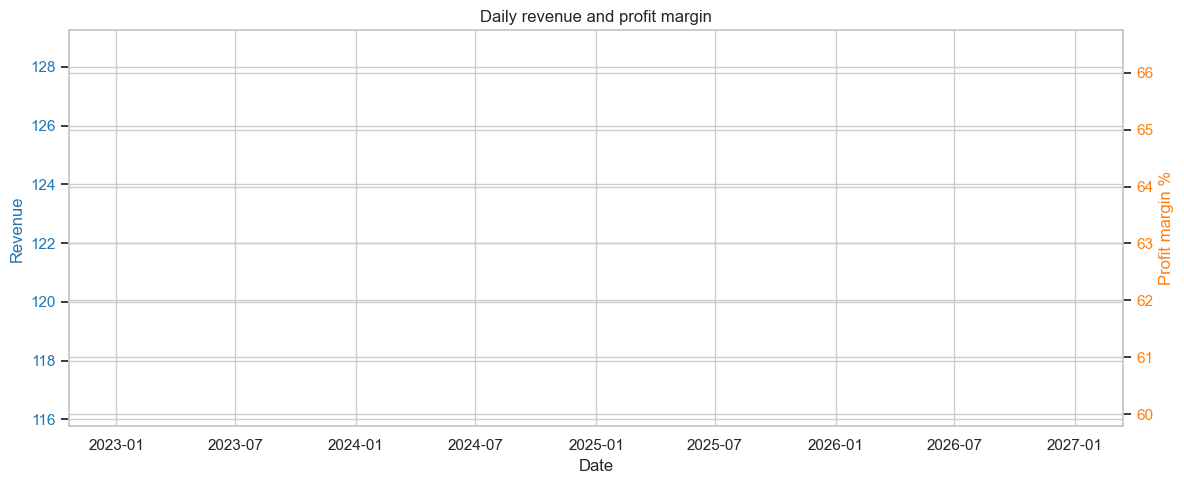

In [8]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(daily["date"], daily["revenue"], label="Revenue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Revenue", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["margin_pct"], label="Margin %", color="tab:orange")
ax2.set_ylabel("Profit margin %", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Daily revenue and profit margin")
fig.tight_layout()
plt.show()

In [9]:
product_stats = (
    sales_df
    .groupby("product")
    .agg(
        units_sold_total=("units_sold", "sum"),
        revenue_total=("revenue", "sum"),
        profit_total=("profit", "sum"),
        avg_margin_pct=("profit_margin_pct", "mean")
    )
    .reset_index()
)

product_stats

,product,units_sold_total,revenue_total,profit_total,avg_margin_pct
0,Korean Bingsu,5,42.5,27.5,64.705882
1,Tofu Pudding,20,80.0,50.0,62.500000


In [10]:
features = product_stats[["units_sold_total", "revenue_total", "profit_total", "avg_margin_pct"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled[:5]

array([[-1., -1., -1.,  1.],
       [ 1.,  1.,  1., -1.]])

In [13]:
# Example: imagine we have a table area_sales with area_code, revenue, profit
# For demonstration, create dummy area_sales or derive if you have customer area info
# area_sales = pd.read_csv("area_sales.csv")  # if exists
# For now assume we merge demo_df with area_sales on area_code

# merged_df = demo_df.merge(area_sales, on="area_code", how="left")
# Replace NaN for missing with 0 for sales
# merged_df["revenue"] = merged_df["revenue"].fillna(0)
# merged_df["profit"] = merged_df["profit"].fillna(0)

# Proceed similarly: select a few numeric columns, scale, cluster